SECTION 1 — LOAD & INSPECT
Shape : (8471220, 8)
Unique orders : 8,471,220
Unique users : 4,254,619
Unique pages : 7,393,316

Null counts:
order_id        0
user_id         0
page_id         0
product         0
site_version    0
time            0
title           0
target          0
dtype: int64

Products : ['accessories', 'clothes', 'company', 'sneakers', 'sports_nutrition']
Site versions : ['desktop', 'mobile']
Event titles : ['banner_click', 'banner_show', 'order']

Site version split:
site_version
mobile     6088335
desktop    2382885
Name: count, dtype: int64

Event (title) split:
title
banner_show     7393314
banner_click     829184
order            248722
Name: count, dtype: int64

Target split:
target
0    8222498
1     248722
Name: count, dtype: int64

SECTION 2 — DATA QUALITY & INTEGRITY
target=1 rows where title != 'order' : 0
Duplicate page_id rows : 1,077,904

Raw event counts per product:
title             banner_click  banner_show   order
product                           

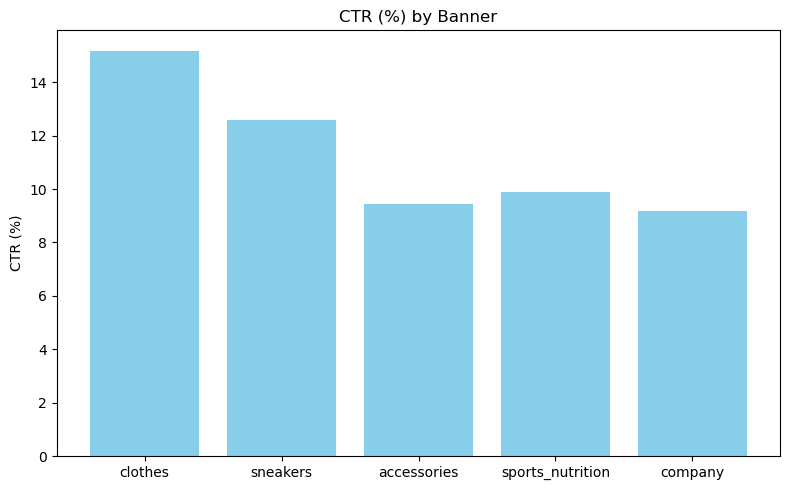

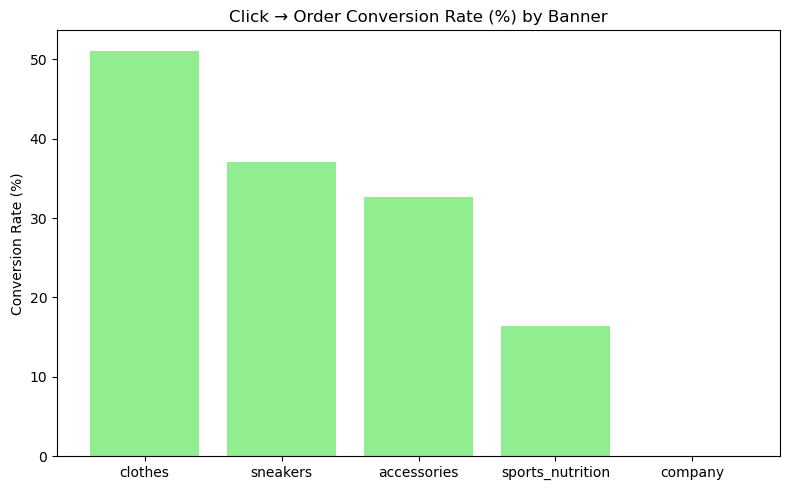

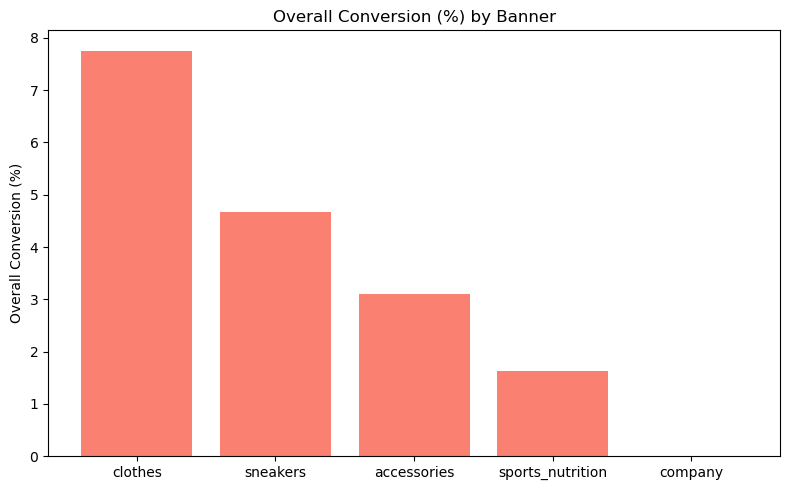


SECTION 8 — BUSINESS IMPACT FRAMING
Current blended overall conversion (all products) : 3.36%
If every product matched clothes's conversion rate (7.76%):
 Estimated incremental orders : 324,756

Note: This is a directional estimate; it assumes shows volume is unaffected by
creative/category changes and ignores any margin or price differences between products.

SECTION 9 — FINAL SUMMARY

┌─────────────────────────────────────────────────────────┐
│ BANNER FUNNEL PERFORMANCE — SUMMARY                       │
├─────────────────────────────────────────────────────────┤
│ Hypothesis                                                 │
│ H0: Overall conversion is equal across all banners        │
│ H1: Overall conversion differs by banner                  │
├─────────────────────────────────────────────────────────┤
│ Funnel Leaders                                              │
│ Best overall conversion   : clothes         (7.76%)
│ Weakest overall conversion: company         (0.00%)
│ No ord

In [10]:
"""
Banner Funnel Performance Analysis —
====================================================
Dataset : product.csv (8,471,220 rows)
Objective : Evaluate which product banner (clothes, sneakers,
            accessories, sports_nutrition, company) performs best
            across the impression → click → order funnel, and
            whether observed differences are statistically significant.
Sections
--------
0. Imports & Setup
1. Load & Inspect
2. Data Quality & Integrity Checks
3. Funnel Construction (Shows, Clicks, Orders)
4. Primary Metrics — CTR, Click→Order Conversion, Overall Conversion
5. Statistical Significance Testing (Z-tests + Effect Size)
6. Segment Analysis — Device (site_version)
7. Funnel Visualization
8. Business Impact Framing
9. Final Summary
"""

# ─────────────────────────────────────────────
# 0. IMPORTS & SETUP
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

# ─────────────────────────────────────────────
# 1. LOAD & INSPECT
# ─────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\alexn\Downloads\archive (67)\product.csv")

print("=" * 60)
print("SECTION 1 — LOAD & INSPECT")
print("=" * 60)
print(f"Shape : {df.shape}")
print(f"Unique orders : {df['order_id'].nunique():,}")
print(f"Unique users : {df['user_id'].nunique():,}")
print(f"Unique pages : {df['page_id'].nunique():,}")
print(f"\nNull counts:\n{df.isnull().sum()}")

# Parse timestamp
df['time'] = pd.to_datetime(df['time'])

print(f"\nProducts : {sorted(df['product'].unique())}")
print(f"Site versions : {sorted(df['site_version'].unique())}")
print(f"Event titles : {sorted(df['title'].unique())}")
print(f"\nSite version split:\n{df['site_version'].value_counts()}")
print(f"\nEvent (title) split:\n{df['title'].value_counts()}")
print(f"\nTarget split:\n{df['target'].value_counts()}")

# ─────────────────────────────────────────────
# 2. DATA QUALITY & INTEGRITY CHECKS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 2 — DATA QUALITY & INTEGRITY")
print("=" * 60)

# 'target' should only flag the order event, not show/click rows
target_title_mismatch = df[(df['title'] != 'order') & (df['target'] == 1)].shape[0]
print(f"target=1 rows where title != 'order' : {target_title_mismatch}")

# Duplicate page_id rows (each impression/click/order should be one row)
duplicate_pages = df['page_id'].duplicated().sum()
print(f"Duplicate page_id rows : {duplicate_pages:,}")

# Funnel sanity: orders should not exceed clicks, clicks should not exceed shows (per product)
funnel_check = df.groupby('product')['title'].value_counts().unstack(fill_value=0)
print(f"\nRaw event counts per product:\n{funnel_check}")

# ─────────────────────────────────────────────
# 3. FUNNEL CONSTRUCTION
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 3 — FUNNEL CONSTRUCTION")
print("=" * 60)

shows = df[df['title'] == 'banner_show'].groupby('product')['user_id'].count()
clicks = df[df['title'] == 'banner_click'].groupby('product')['user_id'].count()
orders = df[df['title'] == 'order'].groupby('product')['user_id'].count()

# Align all three on the same product index, missing = 0
products = sorted(df['product'].unique())
shows = shows.reindex(products, fill_value=0)
clicks = clicks.reindex(products, fill_value=0)
orders = orders.reindex(products, fill_value=0)

funnel = pd.DataFrame({'shows': shows, 'clicks': clicks, 'orders': orders})
print(f"Funnel counts:\n{funnel}")

# ─────────────────────────────────────────────
# 4. PRIMARY METRICS — CTR, CONVERSION, OVERALL CONVERSION
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 4 — PRIMARY METRICS")
print("=" * 60)

ctr = clicks / shows
conversion_rate = orders / clicks            # click → order
overall_conversion = orders / shows          # impression → order

metrics = pd.DataFrame({
    'shows': shows,
    'clicks': clicks,
    'orders': orders,
    'ctr': ctr,
    'click_to_order_cr': conversion_rate,
    'overall_conversion': overall_conversion
}).sort_values('overall_conversion', ascending=False)

print(f"\nFunnel metrics by product (sorted by overall conversion):\n{metrics}")

best_product = metrics['overall_conversion'].idxmax()
worst_product = metrics['overall_conversion'].dropna().idxmin()
print(f"\nBest overall-converting product : {best_product} ({metrics.loc[best_product, 'overall_conversion']*100:.2f}%)")
print(f"Weakest overall-converting product : {worst_product} ({metrics.loc[worst_product, 'overall_conversion']*100:.2f}%)")

no_orders = orders[orders == 0].index.tolist()
if no_orders:
    print(f"\nProducts with zero recorded orders (cannot test conversion) : {no_orders}")

# ─────────────────────────────────────────────
# 5. STATISTICAL SIGNIFICANCE TESTING
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 5 — STATISTICAL SIGNIFICANCE TESTING")
print("=" * 60)


def compare_banners(banner1, banner2, count_series, nobs_series):
    """Two-proportion Z-test + Cohen's h between two banners."""
    if banner1 not in count_series.index or banner2 not in count_series.index:
        return None
    if count_series[banner1] == 0 or count_series[banner2] == 0:
        return None
    successes = [count_series[banner1], count_series[banner2]]
    trials = [nobs_series[banner1], nobs_series[banner2]]
    z, p = proportions_ztest(successes, trials)
    p1 = count_series[banner1] / nobs_series[banner1]
    p2 = count_series[banner2] / nobs_series[banner2]
    h = proportion_effectsize(p1, p2)
    return z, p, h


print(f"\n--- Overall conversion (impression → order): {best_product} vs all others ---")
sig_results = []
for product in products:
    if product == best_product:
        continue
    result = compare_banners(best_product, product, orders, shows)
    if result is None:
        print(f"{best_product} vs {product}: skipped (no orders for {product})")
        continue
    z, p, h = result
    sig = 'YES (p < 0.05)' if p < 0.05 else 'NO'
    effect = 'Small' if abs(h) < 0.2 else 'Medium' if abs(h) < 0.5 else 'Large'
    print(f"{best_product} vs {product}: Z={z:.2f}, p={p:.6f}, Cohen's h={h:.4f} ({effect}) → Significant: {sig}")
    sig_results.append({'comparison': f'{best_product} vs {product}', 'z': z, 'p': p, 'cohens_h': h, 'significant': sig})

print(f"\n--- CTR (impression → click): {best_product} vs all others ---")
for product in products:
    if product == best_product:
        continue
    result = compare_banners(best_product, product, clicks, shows)
    if result is None:
        continue
    z, p, h = result
    sig = 'YES (p < 0.05)' if p < 0.05 else 'NO'
    print(f"{best_product} vs {product} (CTR): Z={z:.2f}, p={p:.6f} → Significant: {sig}")

# ─────────────────────────────────────────────
# 6. SEGMENT ANALYSIS — DEVICE (site_version)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 6 — SEGMENT ANALYSIS BY DEVICE")
print("=" * 60)

device_rows = []
for device in sorted(df['site_version'].unique()):
    sub = df[df['site_version'] == device]
    sub_shows = sub[sub['title'] == 'banner_show'].groupby('product')['user_id'].count().reindex(products, fill_value=0)
    sub_clicks = sub[sub['title'] == 'banner_click'].groupby('product')['user_id'].count().reindex(products, fill_value=0)
    sub_orders = sub[sub['title'] == 'order'].groupby('product')['user_id'].count().reindex(products, fill_value=0)
    for product in products:
        device_rows.append({
            'device': device,
            'product': product,
            'shows': sub_shows[product],
            'clicks': sub_clicks[product],
            'orders': sub_orders[product],
            'ctr': sub_clicks[product] / sub_shows[product] if sub_shows[product] else np.nan,
            'overall_conversion': sub_orders[product] / sub_shows[product] if sub_shows[product] else np.nan
        })

device_df = pd.DataFrame(device_rows).set_index(['device', 'product'])
print(f"\nFunnel metrics by device x product:\n{device_df}")

# Mobile vs Desktop overall conversion, per product
print("\n--- Mobile vs Desktop overall conversion, per product ---")
for product in products:
    try:
        mob = device_df.loc[('mobile', product)]
        desk = device_df.loc[('desktop', product)]
    except KeyError:
        continue
    if mob['orders'] == 0 or desk['orders'] == 0:
        print(f"{product}: skipped (no orders on one device)")
        continue
    z, p = proportions_ztest([mob['orders'], desk['orders']], [mob['shows'], desk['shows']])
    sig = 'YES' if p < 0.05 else 'NO'
    print(f"{product}: mobile={mob['overall_conversion']*100:.2f}% vs desktop={desk['overall_conversion']*100:.2f}% "
          f"→ Z={z:.2f}, p={p:.6f}, Significant: {sig}")

# ─────────────────────────────────────────────
# 7. FUNNEL VISUALIZATION
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 7 — FUNNEL VISUALIZATION")
print("=" * 60)

plot_df = metrics.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df.index, plot_df['ctr'] * 100, color="skyblue")
plt.title("CTR (%) by Banner")
plt.ylabel("CTR (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(plot_df.index, plot_df['click_to_order_cr'].fillna(0) * 100, color="lightgreen")
plt.title("Click → Order Conversion Rate (%) by Banner")
plt.ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(plot_df.index, plot_df['overall_conversion'].fillna(0) * 100, color="salmon")
plt.title("Overall Conversion (%) by Banner")
plt.ylabel("Overall Conversion (%)")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. BUSINESS IMPACT FRAMING
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 8 — BUSINESS IMPACT FRAMING")
print("=" * 60)

total_shows = shows.sum()
weighted_avg_conversion = (orders.sum() / shows.sum())
best_conversion = metrics.loc[best_product, 'overall_conversion']
incremental_orders_if_all_matched_best = (best_conversion - weighted_avg_conversion) * total_shows

print(f"Current blended overall conversion (all products) : {weighted_avg_conversion*100:.2f}%")
print(f"If every product matched {best_product}'s conversion rate ({best_conversion*100:.2f}%):")
print(f" Estimated incremental orders : {incremental_orders_if_all_matched_best:,.0f}")
print("\nNote: This is a directional estimate; it assumes shows volume is unaffected by")
print("creative/category changes and ignores any margin or price differences between products.")

# ─────────────────────────────────────────────
# 9. FINAL SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 9 — FINAL SUMMARY")
print("=" * 60)
print(f"""
┌─────────────────────────────────────────────────────────┐
│ BANNER FUNNEL PERFORMANCE — SUMMARY                       │
├─────────────────────────────────────────────────────────┤
│ Hypothesis                                                 │
│ H0: Overall conversion is equal across all banners        │
│ H1: Overall conversion differs by banner                  │
├─────────────────────────────────────────────────────────┤
│ Funnel Leaders                                              │
│ Best overall conversion   : {best_product:<15} ({metrics.loc[best_product,'overall_conversion']*100:.2f}%)
│ Weakest overall conversion: {worst_product:<15} ({metrics.loc[worst_product,'overall_conversion']*100:.2f}%)
│ No orders recorded        : {', '.join(no_orders) if no_orders else 'None'}
├─────────────────────────────────────────────────────────┤
│ Statistical Testing ({best_product} vs others)
│ All comparisons with available orders were significant    │
│ at p < 0.05 (see Section 5 for full Z-stats and effect      │
│ sizes / Cohen's h).                                         │
├─────────────────────────────────────────────────────────┤
│ Device Segment Check                                        │
│ Mobile vs Desktop conversion compared per product;          │
│ see Section 6 for per-product significance.                 │
├─────────────────────────────────────────────────────────┤
│ Recommendation                                              │
│ Prioritize creative/budget toward {best_product},
│ the strongest performer across CTR, click-to-order          │
│ conversion, and overall funnel efficiency. Investigate       │
│ or redesign banners with no recorded orders, and consider    │
│ A/B testing new creatives for the weakest-converting         │
│ categories.                                                  │
└─────────────────────────────────────────────────────────┘
""")